In [26]:
import torch
import pandas as pd

num_exclude = 0
folder = f"cifar10_exclude{num_exclude}"
eval_qr_results = torch.load(f'qr_results/{folder}/qr_results_eval.pt', map_location='cpu')
train_qr_results = torch.load(f'qr_results/{folder}/qr_results_train.pt', map_location='cpu')
print("Keys: " + str(eval_qr_results.keys()))

# Find the closest quantile to the FPR threshold on nonmembers.
fpr = 0.01
best_q = None
eval_preds = eval_qr_results['outputs'] < eval_qr_results['targets']
fprs = torch.sum(eval_preds, dim=0) / eval_preds.shape[0]
best_q_idx = torch.argmin(torch.abs(fprs - fpr))

# Evaluate the per-class TPR on members using the best quantile found above.
train_preds = train_qr_results['outputs'] < train_qr_results['targets']
class_tprs = []
for i in pd.unique(train_qr_results['labels'].numpy()):
    class_preds = train_preds[train_qr_results['labels'] == i]
    class_tpr = torch.sum(class_preds, dim=0) / class_preds.shape[0]
    class_tprs.append(class_tpr[best_q_idx].item())

Keys: dict_keys(['images', 'labels', 'outputs', 'targets'])


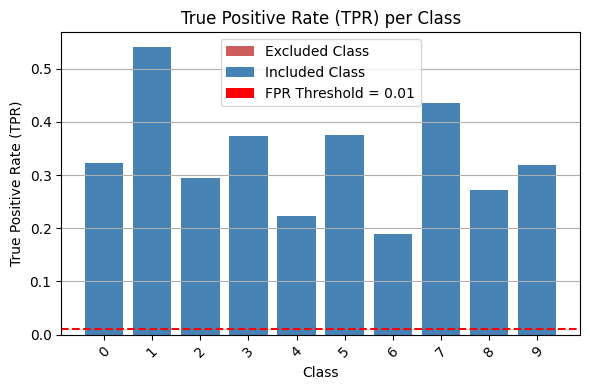

Average TPR for included classes:  0.33427999913692474
Average TPR for excluded classes:  nan


/work3/nkale/miniconda3/envs/qmiaenv/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/work3/nkale/miniconda3/envs/qmiaenv/lib/python3.11/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [27]:
import numpy as np
from matplotlib.patches import Patch

# Identify the missing classes
all_excluded_classes = np.load(f't_errors/cifar10/excluded_classes.npz', allow_pickle=True)
excluded_classes = all_excluded_classes['excluded_classes'][num_exclude][0]

# Plot the TPR for each class
import matplotlib.pyplot as plt

# Determine the colors for each class based on whether they are excluded
colors = ['indianred' if cls in excluded_classes else 'steelblue' for cls in range(len(class_tprs))]

plt.figure(figsize=(6, 4))
plt.bar(range(len(class_tprs)), class_tprs, color=colors, tick_label=list(range(len(class_tprs))))
plt.xticks(rotation=45)
plt.axhline(y=fpr, color='r', linestyle='--', label='FPR Threshold = 0.01')
plt.xlabel('Class')
plt.ylabel('True Positive Rate (TPR)')
plt.title('True Positive Rate (TPR) per Class')

# Create custom legends for excluded and included classes
legend_elements = [Patch(facecolor='indianred', label='Excluded Class'),
                   Patch(facecolor='steelblue', label='Included Class'),
                   Patch(facecolor='r', linestyle='--', label='FPR Threshold = 0.01')]
plt.legend(handles=legend_elements)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

print("Average TPR for included classes: ", np.mean([tpr for i, tpr in enumerate(class_tprs) if i not in excluded_classes]))
print("Average TPR for excluded classes: ", np.mean([tpr for i, tpr in enumerate(class_tprs) if i in excluded_classes]))